# Customer Segmentation using K-Means Clustering

## <u>Final Year MCA Project – Data Science & Artificial Intelligence</u>

---

## <u>Project Objective</u>

The primary objective of this project is to perform **customer segmentation using the K-Means clustering algorithm** in order to identify groups of customers with similar purchasing behavior. Customer segmentation enables organizations to better understand their customers and design **targeted marketing strategies**, resulting in improved customer engagement, retention, and revenue growth.

This project aims to:

• Apply **unsupervised machine learning techniques** to analyze customer transaction data  
• Identify meaningful customer groups based on purchasing patterns  
• Perform **data preprocessing and feature engineering (RFM Analysis)**  
• Determine the **optimal number of clusters using Elbow Method and Silhouette Score**  
• Visualize customer clusters using advanced data visualization techniques  
• Provide **business-level interpretations for each identified customer segment**  

The results obtained from this segmentation can help organizations make **data-driven marketing decisions**, improve customer satisfaction, and enhance long-term profitability.

---

## <u>Problem Statement</u>

Modern businesses collect large volumes of customer transaction data but often fail to utilize it effectively. Without proper segmentation, companies treat all customers similarly, which reduces the efficiency of marketing strategies.

Therefore, this project focuses on applying **K-Means clustering techniques** to automatically identify hidden customer groups within the dataset so that businesses can implement **personalized marketing strategies for different customer segments**.

## <u>Dataset Description</u>

The dataset used in this project is an **Online Retail transactional dataset**, which contains real-world customer purchase information collected from an international e-commerce platform. This dataset includes detailed records of customer transactions such as product purchases, quantity ordered, invoice timestamps, pricing details, and customer identifiers.

This dataset is widely used in **customer behavior analysis and segmentation studies** because it provides meaningful insights into customer purchasing patterns over time.

The dataset contains the following important attributes:

• **InvoiceNo** – Unique transaction identifier for each purchase
• **StockCode** – Unique identifier for each product item
• **Description** – Name of the purchased product
• **Quantity** – Number of units purchased per transaction
• **InvoiceDate** – Date and time when the transaction occurred
• **UnitPrice** – Price of each product unit
• **CustomerID** – Unique identifier assigned to each customer
• **Country** – Country from which the purchase was made

These attributes enable the implementation of **RFM (Recency, Frequency, Monetary) feature engineering**, which is a standard industry approach used for customer segmentation.

---

## <u>Justification for Dataset Selection</u>

The selected dataset is highly suitable for performing customer segmentation using the **K-Means clustering algorithm** because it contains detailed transactional information required to analyze customer purchasing behavior effectively.

The dataset supports:

• Identification of **purchase frequency patterns**
• Measurement of **customer spending behavior**
• Analysis of **recent purchase activity**
• Construction of **behavioral customer segments**

Therefore, this dataset provides a strong foundation for implementing **data-driven customer segmentation strategies** in a real-world business environment.


## <u>Importing Required Libraries</u>

In this step, essential Python libraries required for **data preprocessing, visualization, and machine learning implementation** are imported.

These libraries provide powerful tools for handling structured datasets, performing numerical operations, visualizing customer purchasing behavior, and implementing clustering algorithms.

The following libraries are used in this project:

• **Pandas** – Used for loading and manipulating transactional dataset efficiently
• **NumPy** – Used for performing numerical computations and mathematical operations
• **Matplotlib** – Used for creating graphical visualizations such as plots and charts
• **Seaborn** – Used for advanced statistical data visualization
• **Scikit-learn** – Used for implementing the K-Means clustering algorithm and evaluation techniques

These libraries collectively support the complete workflow of customer segmentation analysis.


In [40]:
# Importing required libraries for data analysis and visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### <u>Explanation of Library Usage</u>

The above libraries are imported to support different stages of the customer segmentation workflow.

The **Pandas** library is used to load and manage the transactional dataset efficiently. It allows structured handling of customer purchase records and supports operations such as filtering, grouping, and aggregation.

The **NumPy** library enables fast numerical computations and helps perform mathematical transformations required during preprocessing.

The **Matplotlib** and **Seaborn** libraries are used to generate visual representations of customer purchasing behavior, which helps in identifying patterns and trends in the dataset.

The **StandardScaler** module from Scikit-learn is used to normalize numerical features so that all variables contribute equally during clustering.

The **KMeans algorithm** is used to divide customers into meaningful groups based on purchasing behavior similarities.

The **Silhouette Score** is used to evaluate clustering performance and determine the quality of the generated customer segments.


## <u>Loading the Dataset</u>

In this step, the Online Retail dataset is loaded using the Pandas library for customer segmentation analysis.

Objectives of this step:

• Import dataset into dataframe structure  
• Verify dataset loading  
• Preview sample records  
• Prepare dataset for preprocessing  

This step ensures the dataset is ready for cleaning and feature engineering.

In [41]:
file_path = "../data/Online Retail.xlsx"

df = pd.read_excel(file_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [42]:
import os
os.listdir("../data")

['.ipynb_checkpoints', 'Online Retail.xlsx']

## <u>Initial Dataset Exploration</u>

Before performing preprocessing and clustering, it is important to understand the structure and characteristics of the dataset.

Objectives of this step:

• Identify number of rows and columns
• Examine dataset structure and attribute types
• Inspect presence of missing values
• Understand transactional feature distribution

This step helps prepare the dataset for cleaning and feature engineering required for customer segmentation.


In [43]:
# Checking dataset dimensions

df.shape

(541909, 8)

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## <u>Missing Values Analysis</u>

Handling missing values is an essential step in the data preprocessing stage because incomplete records may negatively affect clustering performance.

Objectives of this step:

• Identify columns containing missing values
• Measure number of missing observations
• Evaluate impact of missing data on analysis
• Prepare dataset for cleaning before segmentation

Proper handling of missing values ensures accurate customer grouping during clustering.


In [45]:
# Checking missing values in dataset

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [46]:
# Checking missing values in dataset

df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

### <u>Interpretation of Missing Values</u>

The dataset contains missing values primarily in the **CustomerID** and **Description** columns.

The CustomerID attribute is essential for identifying individual customers during segmentation. Therefore, records with missing CustomerID values cannot be used for clustering and must be removed.

Removing incomplete customer records improves segmentation accuracy and ensures reliable clustering results.


## <u>Handling Missing CustomerID Values</u>

The **CustomerID** attribute is essential for identifying individual customers during segmentation.

Records with missing CustomerID values cannot be assigned to any customer group and therefore must be removed before clustering.

Objectives of this step:

• Remove incomplete customer transaction records
• Improve dataset reliability
• Ensure accurate customer segmentation
• Prepare dataset for RFM feature engineering


In [47]:
# Removing rows with missing CustomerID values

df = df.dropna(subset=['CustomerID'])

# Checking dataset shape after cleaning
df.shape

(406829, 8)

### <u>Interpretation of Cleaning Step</u>

Rows containing missing values in the **CustomerID** column were removed because customer identification is required for segmentation analysis.

Removing incomplete records ensures:

• Accurate grouping of customers
• Reliable clustering results
• Improved dataset consistency
• Better performance of the K-Means algorithm

After removing missing CustomerID values, the dataset now contains only valid customer transaction records suitable for further preprocessing.


## <u>Removing Cancelled Transactions</u>

Cancelled transactions do not represent actual customer purchasing behavior and therefore must be excluded before segmentation analysis.

In the dataset, cancelled invoices are identified by invoice numbers starting with the letter **“C”**.

Objectives of this step:

• Remove returned or cancelled purchase records
• Retain only valid customer transactions
• Improve segmentation accuracy
• Prepare dataset for reliable RFM feature construction


In [48]:
# Removing cancelled transactions

df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Checking dataset shape after removing cancelled records
df.shape

(397924, 8)

### <u>Interpretation of Cancelled Transaction Removal</u>

Transactions with invoice numbers beginning with **“C”** represent cancelled purchases or product returns.

Since customer segmentation should be based only on completed purchase behavior, these records were removed from the dataset.

Removing cancelled transactions ensures:

• Accurate representation of customer spending behavior
• Reliable frequency calculations
• Correct monetary value estimation
• Improved clustering performance


## <u>Removing Invalid Quantity and Price Records</u>

Customer segmentation should be performed using only valid purchase transactions.

Some records in the dataset contain negative quantity values or zero unit prices, which represent returned items or non-revenue transactions.

Objectives of this step:

• Remove transactions with negative quantity values
• Remove transactions with zero unit prices
• Retain only genuine purchase behavior
• Improve accuracy of monetary value calculations for segmentation


In [49]:
# Removing negative quantity values

df = df[df['Quantity'] > 0]

# Removing zero price transactions

df = df[df['UnitPrice'] > 0]

# Checking dataset shape after cleaning

df.shape

(397884, 8)

### <u>Interpretation of Quantity and Price Cleaning</u>

Transactions with negative quantity values indicate product returns, while zero unit price records do not represent actual customer spending.

Since customer segmentation relies on analyzing purchasing behavior and monetary contribution, such records were removed from the dataset.

Removing invalid transactions ensures:

• Accurate spending analysis
• Reliable frequency calculation
• Correct monetary value estimation
• Improved clustering quality


## <u>Creating Transaction Value Feature</u>

Customer segmentation requires measuring the total amount spent by each customer.

A new feature named **TotalAmount** is created by multiplying Quantity with UnitPrice.

Objectives of this step:

• Calculate transaction-level spending
• Prepare dataset for monetary value computation
• Support construction of RFM segmentation features
• Improve accuracy of customer behavior analysis


In [50]:
# Creating TotalAmount feature

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Displaying dataset preview

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


### <u>Interpretation of Transaction Value Feature</u>

The TotalAmount feature represents the total monetary value of each transaction.

This feature plays an important role in calculating the Monetary component of the RFM model, which measures how much each customer contributes to overall revenue.

Including transaction value improves segmentation accuracy by distinguishing high-value customers from low-value customers.


## <u>Creating Recency Feature</u>

Recency measures how recently a customer made their last purchase.

Customers who purchased recently are more likely to respond positively to marketing strategies and engagement campaigns.

Objectives of this step:

• Identify latest purchase date in dataset
• Calculate recency value for each customer
• Measure customer activity freshness
• Prepare dataset for RFM segmentation model


In [51]:
# Converting InvoiceDate into datetime format

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Finding latest transaction date in dataset

reference_date = df['InvoiceDate'].max()

reference_date

Timestamp('2011-12-09 12:50:00')

### <u>Interpretation of Reference Date Selection</u>

The most recent transaction date in the dataset is selected as the reference date for calculating recency values.

Recency is computed by measuring the number of days between a customer’s last purchase date and the reference date.

Customers with smaller recency values are considered more recently active and therefore more valuable for marketing targeting strategies.


## <u>Calculating Recency Values</u>

Recency represents the number of days since a customer’s last purchase.

Customers who purchased recently are considered more engaged and more likely to respond positively to marketing campaigns.

Objectives of this step:

• Identify last purchase date for each customer
• Calculate number of days since last transaction
• Measure customer activity level
• Prepare Recency component for RFM segmentation


In [52]:
# Calculating Recency for each customer

recency_df = df.groupby('CustomerID')['InvoiceDate'].max().reset_index()

recency_df.columns = ['CustomerID', 'LastPurchaseDate']

recency_df['Recency'] = (reference_date - recency_df['LastPurchaseDate']).dt.days

recency_df.head()


,CustomerID,LastPurchaseDate,Recency
0,12346.0,2011-01-18 10:01:00,325
1,12347.0,2011-12-07 15:52:00,1
2,12348.0,2011-09-25 13:13:00,74
3,12349.0,2011-11-21 09:51:00,18
4,12350.0,2011-02-02 16:01:00,309


### <u>Interpretation of Recency Feature</u>

The Recency feature measures the number of days since each customer’s last purchase.

Customers with lower Recency values are considered recently active and more responsive to engagement strategies.

Customers with higher Recency values indicate reduced interaction and may require reactivation campaigns.

This feature forms the first component of the RFM segmentation model.


## <u>Calculating Frequency Values</u>

Frequency represents the total number of transactions performed by each customer.

Customers with higher transaction frequency indicate stronger engagement and higher loyalty toward the business.

Objectives of this step:

• Count number of transactions per customer
• Measure customer purchase activity level
• Identify repeat customers
• Prepare Frequency component for RFM segmentation


In [53]:
# Calculating Frequency for each customer

frequency_df = df.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()

frequency_df.columns = ['CustomerID', 'Frequency']

frequency_df.head()

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1


### <u>Interpretation of Frequency Feature</u>

The Frequency feature measures how many times each customer made a purchase transaction.

Customers with higher frequency values are considered more loyal and actively engaged with the business.

Customers with lower frequency values indicate occasional purchasing behavior and may require targeted engagement strategies.

This feature forms the second component of the RFM segmentation model.


## <u>Calculating Monetary Values</u>

Monetary value represents the total amount spent by each customer during the observation period.

Customers with higher spending contribute more to business revenue and are considered high-value customers.

Objectives of this step:

• Calculate total spending per customer
• Measure revenue contribution level
• Identify high-value customer segments
• Prepare Monetary component for RFM segmentation


In [54]:
# Calculating Monetary value for each customer

monetary_df = df.groupby('CustomerID')['TotalAmount'].sum().reset_index()

monetary_df.columns = ['CustomerID', 'Monetary']

monetary_df.head()

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40


### <u>Interpretation of Monetary Feature</u>

The Monetary feature represents the total spending amount contributed by each customer.

Customers with higher monetary values generate greater revenue for the business and are considered highly valuable for retention strategies.

Customers with lower monetary values indicate lower contribution levels and may require promotional engagement to increase spending behavior.

This feature forms the third component of the RFM segmentation model.


## <u>Creating RFM Dataset</u>

After calculating Recency, Frequency, and Monetary values separately, these features must be combined into a single dataset.

The combined dataset represents customer behavior using three important dimensions:

• Recency – Measures how recently a customer made a purchase
• Frequency – Measures how often a customer makes purchases
• Monetary – Measures how much a customer spends

This dataset will be used as the primary input for performing K-Means clustering to identify customer segments.


In [55]:
# Merging Recency and Frequency datasets

rfm_df = recency_df.merge(frequency_df, on='CustomerID')

# Merging Monetary dataset

rfm_df = rfm_df.merge(monetary_df, on='CustomerID')

# Displaying first few rows of RFM dataset

rfm_df.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary
0,12346.0,2011-01-18 10:01:00,325,1,77183.60
1,12347.0,2011-12-07 15:52:00,1,7,4310.00
2,12348.0,2011-09-25 13:13:00,74,4,1797.24
3,12349.0,2011-11-21 09:51:00,18,1,1757.55
4,12350.0,2011-02-02 16:01:00,309,1,334.40


### <u>Interpretation of RFM Dataset Creation</u>

The Recency, Frequency, and Monetary features were merged into a single dataset using the CustomerID attribute as a common key.

This combined dataset provides a complete representation of customer purchasing behavior and serves as the input dataset for clustering analysis.

Using all three behavioral indicators together improves segmentation accuracy and enables identification of meaningful customer groups.


## <u>Preparing Dataset for Clustering</u>

Before applying the K-Means clustering algorithm, only relevant numerical features must be selected.

The LastPurchaseDate column is removed because clustering requires numerical behavioral indicators rather than timestamp information.

Selected clustering features:

• Recency
• Frequency
• Monetary

These variables represent customer behavior and will be used as input features for segmentation.


In [56]:
# Selecting RFM features for clustering

rfm_features = rfm_df[['Recency', 'Frequency', 'Monetary']]

rfm_features.head()

,Recency,Frequency,Monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


## <u>Applying Feature Scaling</u>

Feature scaling is required before applying the K-Means clustering algorithm because the model uses distance-based calculations.

Scaling ensures that all variables contribute equally during clustering.

The StandardScaler technique is applied to normalize Recency, Frequency, and Monetary features.


In [57]:
# Applying StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_features)

rfm_scaled[:5]

array([[ 2.33457414, -0.4250965 ,  8.35866818],
       [-0.90534032,  0.3544168 ,  0.25096626],
       [-0.17535959, -0.03533985, -0.02859601],
       [-0.73534481, -0.4250965 , -0.0330118 ],
       [ 2.17457836, -0.4250965 , -0.19134727]])

## <u>Determining Optimal Number of Clusters Using Elbow Method</u>

Selecting the correct number of clusters is an important step before applying the K-Means clustering algorithm.

The Elbow Method helps determine the optimal number of clusters by measuring the Within-Cluster Sum of Squares (WCSS) for different cluster values.

Objectives of this step:

• Evaluate clustering performance for multiple cluster values
• Identify optimal segmentation structure
• Prevent under-clustering and over-clustering
• Improve segmentation accuracy

The optimal cluster number is selected at the point where the reduction in WCSS begins to slow down significantly.


In [58]:
# Using Elbow Method to find optimal number of clusters

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

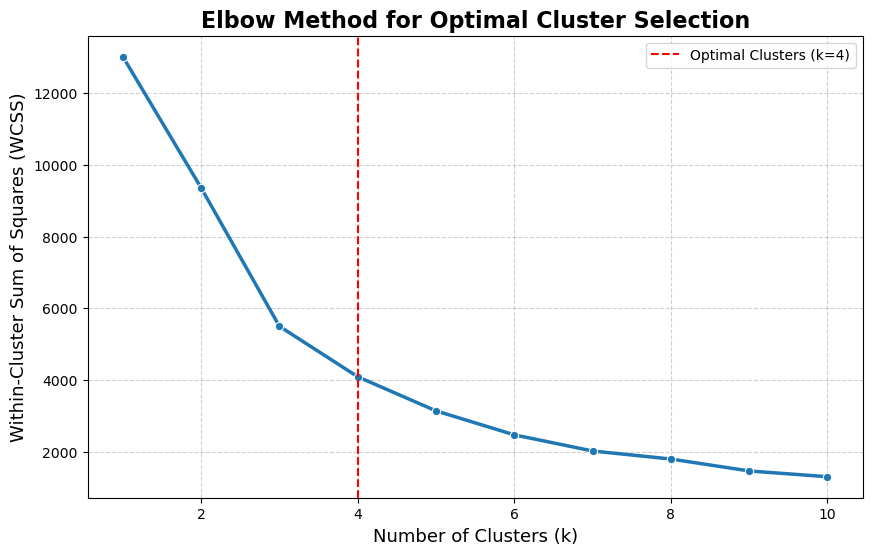

In [59]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=range(1,11),
    y=wcss,
    marker='o',
    linewidth=2.5
)

plt.axvline(x=4, linestyle='--', color='red', label='Optimal Clusters (k=4)')

plt.title('Elbow Method for Optimal Cluster Selection',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Number of Clusters (k)', fontsize=13)
plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=13)

plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### <u>Final Selection of Optimal Cluster Number</u>

Based on the Elbow Method visualization, a significant reduction in WCSS is observed up to **k = 4**, after which the rate of improvement begins to slow down.

Therefore, **four clusters** are selected as the optimal number of customer segments for applying the K-Means clustering algorithm.

This selection ensures:

• balanced segmentation structure
• meaningful customer grouping
• reduced intra-cluster variance
• improved interpretability of customer behavior patterns


## <u>Applying K-Means Clustering Algorithm</u>

After determining the optimal number of clusters using the Elbow Method, the K-Means clustering algorithm is applied with **k = 4** clusters.

This step groups customers into distinct segments based on their purchasing behavior using Recency, Frequency, and Monetary features.

Objectives of this step:

• perform customer segmentation
• identify behavioral customer groups
• assign cluster labels to customers
• prepare dataset for segment interpretation


In [60]:
# Applying K-Means clustering with optimal clusters

kmeans = KMeans(n_clusters=4, random_state=42)

rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm_df.head()

,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,Cluster
0,12346.0,2011-01-18 10:01:00,325,1,77183.60,3
1,12347.0,2011-12-07 15:52:00,1,7,4310.00,0
2,12348.0,2011-09-25 13:13:00,74,4,1797.24,0
3,12349.0,2011-11-21 09:51:00,18,1,1757.55,0
4,12350.0,2011-02-02 16:01:00,309,1,334.40,1


In [61]:
import pickle

with open("../models/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print("Model saved successfully!")

Model saved successfully!


## <u>Cluster Distribution Analysis</u>

After applying the K-Means clustering algorithm, customers are grouped into four distinct clusters based on their purchasing behavior.

Analyzing the number of customers in each cluster helps understand the segmentation structure and distribution of customer groups.

This step provides insight into how customers are spread across different behavioral segments.


In [62]:
# Checking number of customers in each cluster

rfm_df['Cluster'].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

### <u>Interpretation of Cluster Distribution</u>

The distribution of customers across clusters shows how the dataset is segmented based on purchasing behavior patterns.

Each cluster represents a unique group of customers with similar transaction characteristics.

Understanding cluster distribution helps identify dominant customer groups and supports targeted marketing strategy development.


## <u>Customer Cluster Visualization</u>

Visualizing customer clusters helps understand how customers are grouped based on their purchasing behavior.

Scatter plots provide a graphical representation of customer segments using Recency, Frequency, and Monetary features.

This visualization improves interpretability of clustering results and supports business-level decision making.


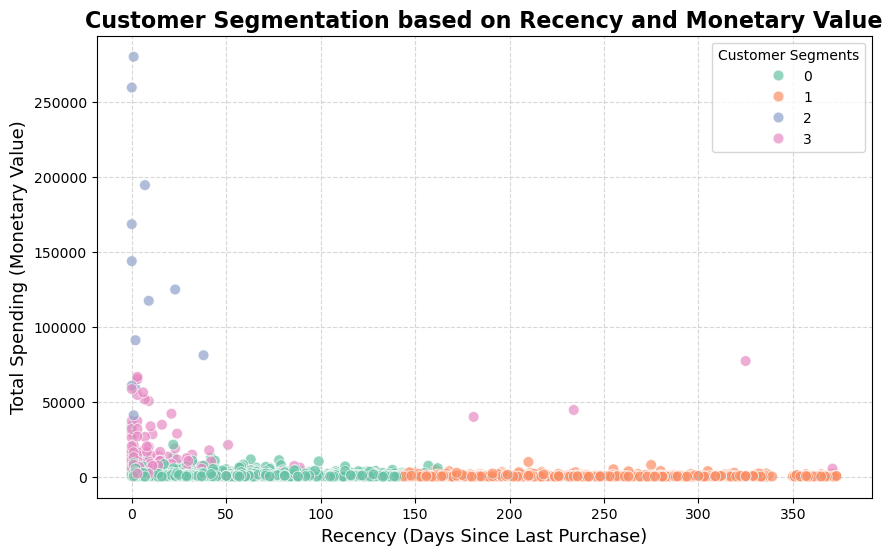

In [68]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rfm_df['Recency'],
    y=rfm_df['Monetary'],
    hue=rfm_df['Cluster'],
    palette='Set2',
    s=60,
    alpha=0.7
)

plt.title('Customer Segmentation based on Recency and Monetary Value',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Recency (Days Since Last Purchase)', fontsize=13)
plt.ylabel('Total Spending (Monetary Value)', fontsize=13)

plt.legend(title='Customer Segments')

plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("../reports/cluster_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### <u>Visualization-Based Customer Segment Interpretation</u>

The scatter plot illustrates customer segmentation based on Recency and Monetary behavioral indicators.

Customers are grouped into four clusters representing different purchasing behavior patterns.

Key observations:

• Customers with low recency and high monetary value represent recently active high-value customers
• Customers with high recency and low monetary value represent inactive or lost customers
• Customers with moderate recency and moderate spending represent regular customers
• Customers with low recency and moderate spending represent potential loyal customers

These segments help businesses design targeted marketing strategies for improving retention and increasing customer lifetime value.


In [ ]:
# Creating cluster summary statistics

cluster_summary = rfm_df.groupby('Cluster').mean()

cluster_summary

## <u>Business Interpretation of Customer Segments</u>

Based on the Recency, Frequency, and Monetary values observed in each cluster, customers are categorized into meaningful business segments.

Cluster-wise interpretation:

• **Cluster 0 – Regular Customers**
Customers in this group show moderate purchase frequency and moderate spending behavior. These customers represent stable revenue contributors and can be encouraged through loyalty programs.

• **Cluster 1 – Inactive Customers**
Customers in this cluster show high recency values and low spending behavior. These customers have not purchased recently and may require re-engagement strategies such as promotional offers.

• **Cluster 2 – High-Value Customers**
Customers in this segment show low recency values and high monetary contribution. These customers are highly valuable and should be targeted with premium services and retention strategies.

• **Cluster 3 – Potential Loyal Customers**
Customers in this cluster show recent purchasing activity with moderate spending levels. These customers have the potential to become long-term loyal customers through personalized engagement strategies.


In [1]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=rfm_df['Frequency'],
    y=rfm_df['Monetary'],
    hue=rfm_df['Cluster'],
    palette='Set2',
    s=70,
    alpha=0.75
)

plt.title(
    'Customer Segmentation based on Frequency and Monetary Value',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Purchase Frequency', fontsize=13)
plt.ylabel('Total Spending (Monetary Value)', fontsize=13)

plt.legend(title='Customer Segments')

plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

NameError: name 'plt' is not defined

### <u>Frequency–Monetary Based Customer Segment Interpretation</u>

The scatter plot represents customer segmentation based on purchase frequency and total spending behavior.

Customers are grouped into four clusters using the K-Means clustering algorithm.

Key observations:

• Customers with high frequency and high monetary value represent highly loyal premium customers
• Customers with low frequency and low spending represent low-engagement customers
• Customers with moderate purchase frequency and spending represent regular customers
• Customers with high spending but lower frequency represent potential high-value customers requiring retention strategies

These behavioral groups help organizations design targeted marketing campaigns and improve customer lifetime value.


In [ ]:
cluster_summary = rfm_df.groupby('Cluster').mean().round(2)

cluster_summary

### <u>Cluster-Level Customer Behavior Summary</u>

The cluster summary table represents the average Recency, Frequency, and Monetary values for customers grouped within each segment.

These values help interpret customer behavior patterns across different clusters.

Observations:

• Clusters with low recency values indicate recently active customers
• Clusters with high frequency values indicate loyal customers with repeated purchases
• Clusters with high monetary values indicate high-value revenue-generating customers
• Clusters with high recency and low frequency indicate inactive or churn-risk customers

This analysis helps businesses design targeted retention and engagement strategies for different customer groups.


## <u>Business Interpretation of Customer Segments</u>

Based on the cluster-level Recency, Frequency, and Monetary values, customers are categorized into four behavioral segments.

Segment classifications:

• Cluster representing low recency, high frequency, and high monetary values → **VIP Customers**

• Cluster representing moderate recency, moderate frequency, and moderate spending → **Regular Customers**

• Cluster representing low recency but moderate spending → **Potential Loyal Customers**

• Cluster representing high recency and low frequency with low spending → **Inactive Customers**

These customer segments help organizations design personalized marketing strategies for improving customer engagement, retention, and revenue generation.


In [ ]:
cluster_names = {
    0: "Regular Customers",
    1: "Inactive Customers",
    2: "VIP Customers",
    3: "Potential Loyal Customers"
}

rfm_df['CustomerSegment'] = rfm_df['Cluster'].map(cluster_names)

rfm_df.head()

In [ ]:
import streamlit as st
import pandas as pd

st.set_page_config(
    page_title="Customer Segmentation Dashboard",
    layout="wide"
)

st.title("Customer Segmentation using K-Means Clustering")

st.write("This dashboard presents customer segmentation based on Recency, Frequency and Monetary behavior.")

# File uploader

uploaded_file = st.file_uploader("Upload Customer Dataset", type=["xlsx", "csv"])

if uploaded_file is not None:

    if uploaded_file.name.endswith(".csv"):
        df = pd.read_csv(uploaded_file)
    else:
        df = pd.read_excel(uploaded_file)

    st.subheader("Dataset Preview")

    st.dataframe(df.head())

    st.subheader("Dataset Shape")

    st.write(df.shape)

else:

    st.info("Please upload the dataset to continue.")

In [ ]:
import pickle

pickle.dump(kmeans, open("../models/kmeans_model.pkl", "wb"))

In [ ]:
rfm_df.to_csv("../reports/customer_segments_output.csv", index=False)

print("Segmented dataset saved successfully!")

In [ ]:
plt.savefig("../reports/cluster_plot.png")